# Семинар 12: Кластеризация. Понижение размерности.


На сегодняшнем семинаре будем говорить про кластеризацию и про визуализацию.
Также поговорим про метрики качества кластеризации.

Из методов кластеризации рассмотрим:
* k-means
* Иерархическая
* DBSCAN

Визуализацию будем делать с помощью:
* PCA
* t-SNE

Ноутбук частично основан на ноутбуке
https://github.com/Yorko/mlcourse.ai/blob/main/jupyter_russian/topic07_unsupervised/lesson7_part3_kmeans.ipynb

# Кластеризация

__Кластеризация__ &mdash; это метод машинного обучения, который включает группировку данных в пространстве признаков. Теоретически, точки, находящиеся в одной группе, должны иметь схожие свойства, в то время как точки в разных группах должны иметь сильно отличающиеся свойства.

Кластеризация является методом обучения без учителя и распространенным методом статистического анализа данных, используемым во многих областях. В частности используется при составлении портретов пользователей, поиске аномалий. В анализе данных часто прибегают к кластеризации, чтобы получить ценную информацию из наших данных, наблюдая, в какие группы попадают точки.

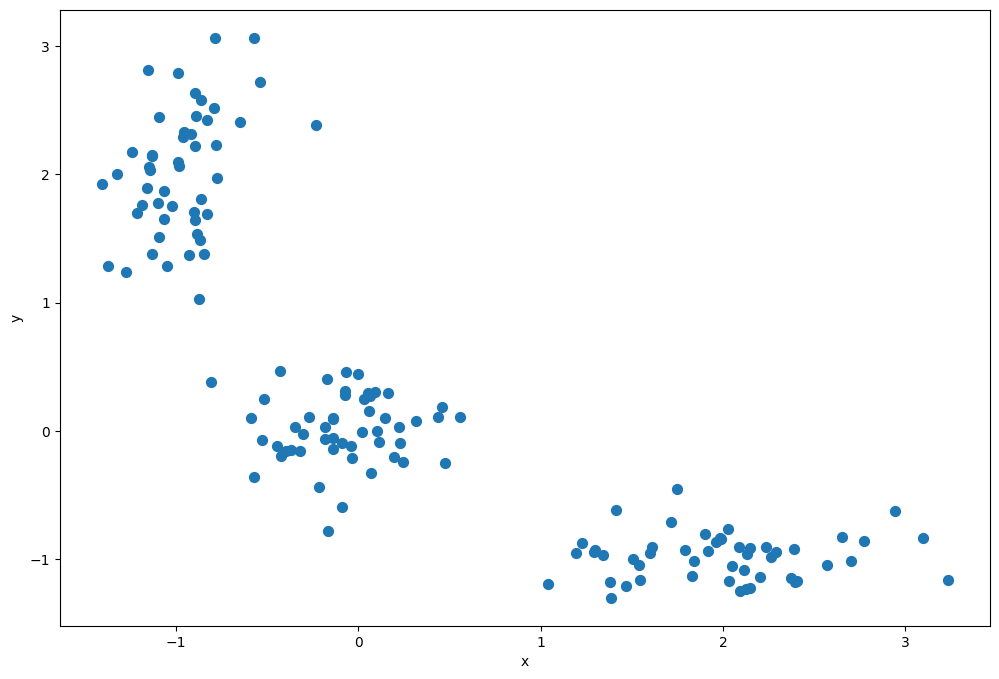

In [ ]:
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

X = np.zeros((150, 2))

np.random.seed(seed=42)
X[:50, 0] = np.random.normal(loc=0.0, scale=.3, size=50)
X[:50, 1] = np.random.normal(loc=0.0, scale=.3, size=50)

X[50:100, 0] = np.random.normal(loc=2.0, scale=.5, size=50)
X[50:100, 1] = np.random.normal(loc=-1.0, scale=.2, size=50)

X[100:150, 0] = np.random.normal(loc=-1.0, scale=.2, size=50)
X[100:150, 1] = np.random.normal(loc=2.0, scale=.5, size=50)

plt.figure(figsize=(12, 8))
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.xlabel('x')
plt.ylabel('y');

## KMeans




Гиперпараметр алгоритма - $K$ - количество кластеров.

Алгоритм можно схематически представить в виде следующих шагов:

1. Инициализируем центры кластеров случайно (должно быть задано количество кластеров).
2. Относим точки к соответствующим кластерам (с минимальным расстоянием до их центра).
3. Производится пересчет центров кластеров по формуле центра масс всех точек принадлежащих кластеру.
4. Пункты 2-3 повторяются до тех пор пока центры кластеров перестанут меняться (сильно).

Также  `sklearn.KMeans` содержит параметры `n_init` (число запусков из различных начальных приближений) и `init`. Есть три способа инициализации центры:
- `k-means++` – "умная" инициализация центров для ускорения сходимости.
- `random` – случайная инициализация центров.
- `ndarray` – заданная инициализация центров.

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 2 2 2 2 2 2 2 2
 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


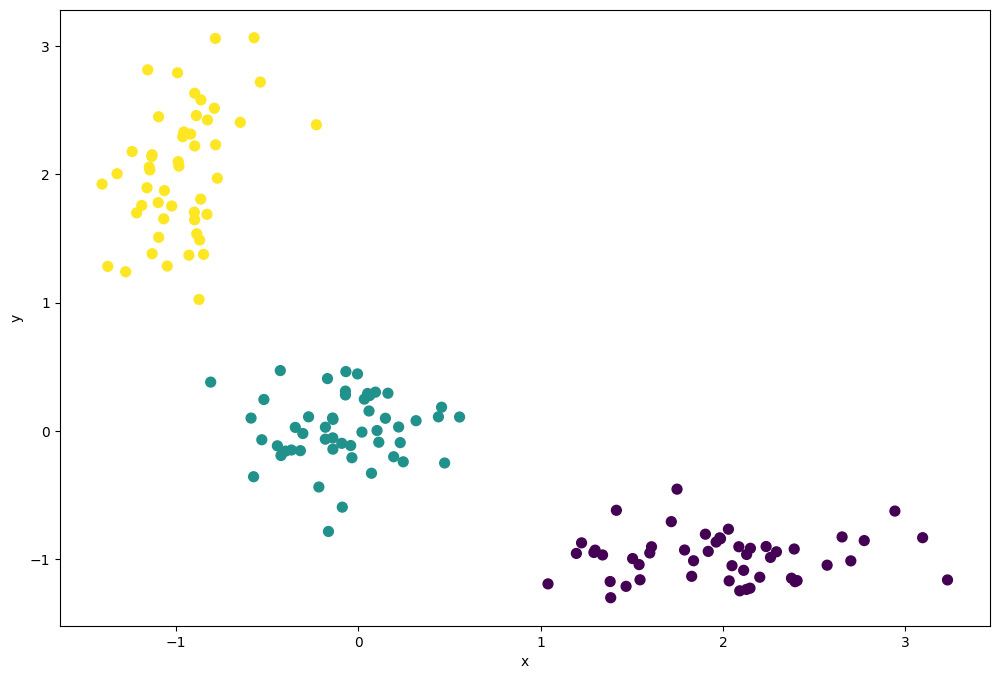

In [ ]:
kmeans = KMeans(n_init = 'auto', n_clusters=3, random_state=1)
kmeans.fit(X)
print(kmeans.labels_) # список из номеров кластеров для каждого объекта обучающей выборки

plt.figure(figsize=(12, 8))
plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, s=50, cmap='viridis') # Ваш код сюда :)
plt.xlabel('x')
plt.ylabel('y');

Что произойдет, если подобрать неверное число кластеров?

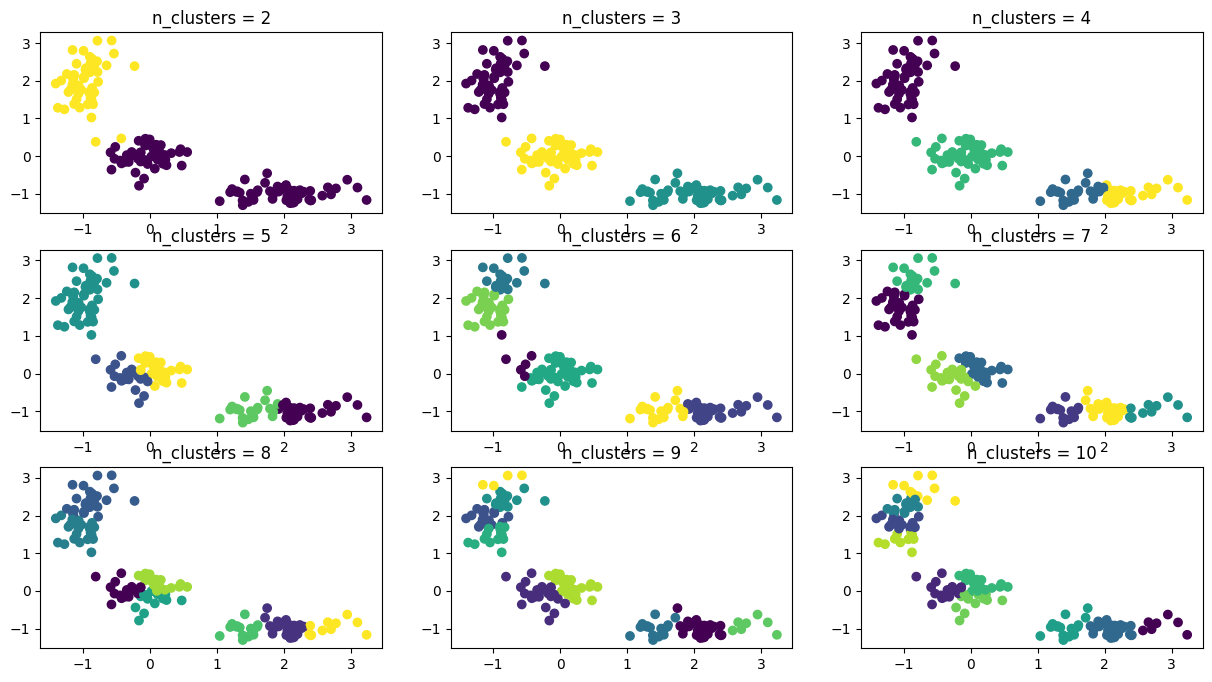

In [ ]:
plt.figure(figsize=(15, 8))
for n_c in range(2, 11):
    kmeans = KMeans(n_init = 'auto', n_clusters = n_c)
    kmeans = kmeans.fit(X)
    clusters = kmeans.predict(X)
    plt.subplot(3, 3, n_c - 1)
    plt.scatter(X[:, 0], X[:, 1], c = clusters) # Ваш код сюда :)
    plt.title('n_clusters = {}'.format(n_c))

plt.show()

Преимущества KMeans:
- Скорость алгоритма. На каждой итерации требуется пересчет только расстояний до центров кластеров.

Недостатки:

- Случайная инициализация центров кластеров, что может привести к различным результатам кластеризации. Для исправления этой проблемы есть `n_init` и `init`

- Обязательно пытается отдать каждому кластеру какие-то объекты, поэтому требуется подбор гиперпарамтера $K$

- Выпуклые, сферообразные кластеры (см. пример ниже)

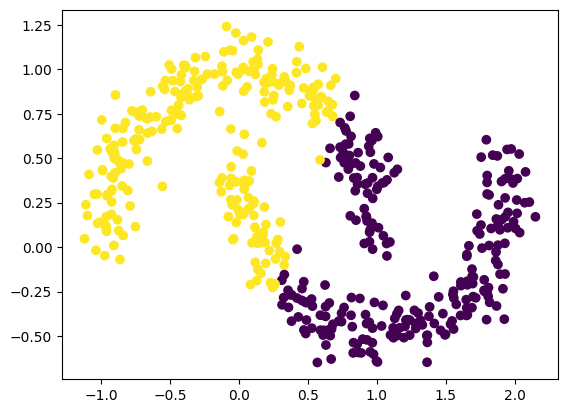

In [ ]:
from sklearn.datasets import make_moons
moons, _ = make_moons(n_samples=500, noise=0.1)
k_means = KMeans(n_init = 'auto', n_clusters = 2)
k_means = k_means.fit(moons)

plt.scatter(moons[:, 0], moons[:, 1], c=k_means.predict(moons)) # Ваш код сюда :)
plt.show()

[Визуализация работы K-Means](https://www.naftaliharris.com/blog/visualizing-k-means-clustering/)

## Оценка качества кластеризации



В случае, когда неизвестны истинные лейблы (внешняя информация), могут быть использованы внутренние меры качества кластеризации, которые оценивают качество структуры кластеров:

* компактность (cohesion) - чем ближе (более похожи) объекты в кластере, тем лучше
* отделимость (separation) - чем дальше друг от друга (менее похожи)  находятся объекты из разных кластеров, тем лучше

Например, **индекс Силуэта** (Silhouette Coefficient):

$$Sil(X, C) = \frac{1}{|C|}\sum_{c_k \in C}\frac{1}{|c_k|}\sum_{x_i \in c_k}\frac{separation(x_i, c_k) - cohension(x_i, c_k)}{max\{separation(x_i, c_k) , cohension(x_i, c_k)\}}$$

где

$separation(x_i, c_k) = min_{c_l \in C ∖ \{c_k\}} \{\frac{1}{|c_l|}\sum_{x_j \in c_l}||x_i - x_j||\}$ - среднее расстояние до объектов ближайшего кластера

$cohension(x_i, c_k) = \frac{1}{|c_k|-1}\sum_{x_j \in c_k}||x_i - x_j||$ - среднее расстояние до объектов того же кластера


$-1 \le Sil(X, C) \le 1$

Чем ближе к 1, тем лучше. Значения около 0 - пересекающиеся кластера. Отрицательные - обычно объектам присовены не те кластеры, так как объекты других кластеров более похожи, чем объекты из одного.

In [ ]:
from sklearn.metrics import silhouette_score

best_k, best_score = None, -1
for k in range(2, 15):
    k_means = KMeans(n_init = 'auto',
                     n_clusters = k)
    k_means = k_means.fit(X)
    clusters = k_means.predict(X)
    score = np.round(silhouette_score(X=X,
                             labels=clusters), 2)
    if score > best_score:
      best_score = score
      best_k = k

print('Best score {}, k = {}'.format(best_score, best_k))

Best score 0.72, k = 3


## Иерархическая кластеризация

Другим вариантом к построению кластеров является иерархический подход, в котором алгоритм жадным образом строит кластеры. Существует два варианта иерархической кластеризации:

1. аггломеративная, в которой алгоритм на каждой итерации объединяет два меньших кластера в один
2. дивизивная, в которой алгоритм на каждой итерации разбивает один кластер на два более мелких
Мы рассмотрим аггломеративный подход к кластеризации (дивизивный можно рассмотреть по аналогии).

Опишем схематически алгоритм аггломеративной иерархической кластеризации, гиперпараметр - метрика расстояния:

* Инициализируем множество кластеров: каждая точка считается отдельным кластером. ($N$ точек - $N$ кластеров)

* На каждой итерации мы объединяем два кластера в один. Объединяющиеся кластера выбираются в соответствии с наименьшим расстоянием (объединяем наиболее похожие кластеры).
* Предыдущий шаг повторяется вплоть до объединения всех точек один кластер.

Одной из популярных метрик расстояния является расстояние Уорда: прирост суммы квадратов расстояний объектов до центра кластера, получаемого в результате их объединения.

$Δ = \sum_{x_i \in A \cup B} (x_i - \overline{x})^2 - \sum_{x_i \in A } (x_i - \overline{a})^2 - \sum_{x_i \in  B} (x_i - \overline{b})^2$



В результате в данном подходе мы можем выбрать любое количество кластеров после завершения процедуры, просто остановив алгоритм на нужном нам шаге. К тому же данный алгоритм гораздо менее чувствителен к выбору метрики между точками, тогда как другие алгоритмы сильно зависят от этого.

Для визуализации иерархической кластеризации удобно строить дендрограммы, в которых разница между уровнями равна выбранному расстоянию объединяющихся на данном этапе кластеров.

Посмотрим на иерархическую кластеризацию на примере:

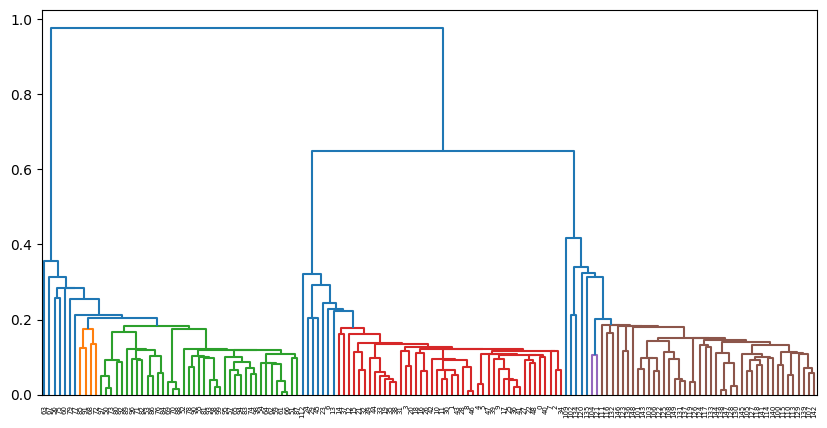

In [ ]:
from scipy.cluster import hierarchy
from scipy.spatial.distance import pdist

distance_mat = pdist(X) # pdist посчитает нам верхний треугольник матрицы попарных расстояний

Z = hierarchy.linkage(distance_mat, 'single') # linkage — реализация агломеративного алгоритма
plt.figure(figsize=(10, 5))
dn = hierarchy.dendrogram(Z, color_threshold=0.2)

Если нет каких-то специализированных условий (например, известно, что кластеров должно быть не более $K$
), то число кластеров можно выбирать по резкому скачку дендрограммы. Кроме того, в некоторых задачах важно понимать, для чего делается кластеризация и доменную область задачи — исходя из этого можно сильно сократить искомое количество кластеров.

## DBSCAN

(Density-based spatial clustering of applications with noise)

Это алгоритм, основанный на плотности — если дан набор объектов в некотором пространстве, алгоритм группирует вместе объекты, которые расположены близко и помечает как выбросы объекты, которые находятся в областях с малой плотностью (ближайшие соседи которых лежат далеко).

Алгоритм имеет два основных гиперпараметра:
1. `eps` &mdash; радиус рассматриваемой окрестности
2. `min_samples` &mdash; число соседей в окрестности

Для выполнения кластеризации DBSCAN точки делятся на основные точки, достижимые по плотности точки и выпадающие следующим образом:

- Точка $p$ является основной точкой, если по меньшей мере `min_samples` точек находятся на расстоянии, не превосходящем
`eps` от неё. Говорят, что эти точки достижимы прямо из $p$.

-  Точка $q$ прямо достижима из $p$, если точка $q$ находится на расстоянии, не большем `eps`, от точки $p$, и $p$ — основная точка.
Точка $q$ достижима из $p$, если имеется путь
$p_1,…,p_n$ где $p_1=p$ и $p_n=q$ , а каждая точка $p_{i+1}$ достижима прямо из $p_i$ (все точки на пути должны быть основными, за исключением $q$).

Все точки, не достижимые из основных точек, считаются выбросами.

Теперь, если $p$ является основной точкой, то она формирует кластер вместе со всеми точками (основными или неосновными), достижимыми из этой точки. Каждый кластер содержит по меньшей мере одну основную точку. Неосновные точки могут быть частью кластера, но они формируют его «край», поскольку не могут быть использованы для достижения других точек.



Рассмотрим диаграмму, параметр `min_samples`=4.

Точка $A$ и другие красные точки являются основными точками, поскольку область с радиусом
`eps` , окружающая эти точки, содержит по меньшей мере 4 точки (включая саму точку). Поскольку все они достижимы друг из друга, точки образуют один кластер. Точки $B$ и $C$ основными не являются, но достижимы из $A$ (через другие основные точки), и также принадлежат кластеру. Точка $N$ является точкой шума, она не является ни основной точкой, ни доступной прямо.

<p><img src="https://upload.wikimedia.org/wikipedia/commons/a/af/DBSCAN-Illustration.svg" alt="DBSCAN-Illustration.svg" width="450" height="450"></a>
<br>Автор: <a href="//commons.wikimedia.org/wiki/User:Chire" title="User:Chire">Chire</a> &mdash; <span class="int-own-work" lang="ru">собственная работа</span>, <a href="https://creativecommons.org/licenses/by-sa/3.0" title="Creative Commons Attribution-Share Alike 3.0">CC BY-SA 3.0</a>

Посмотрим на результаты кластеризации при разном выборе параметров `eps` и `min_samples`.

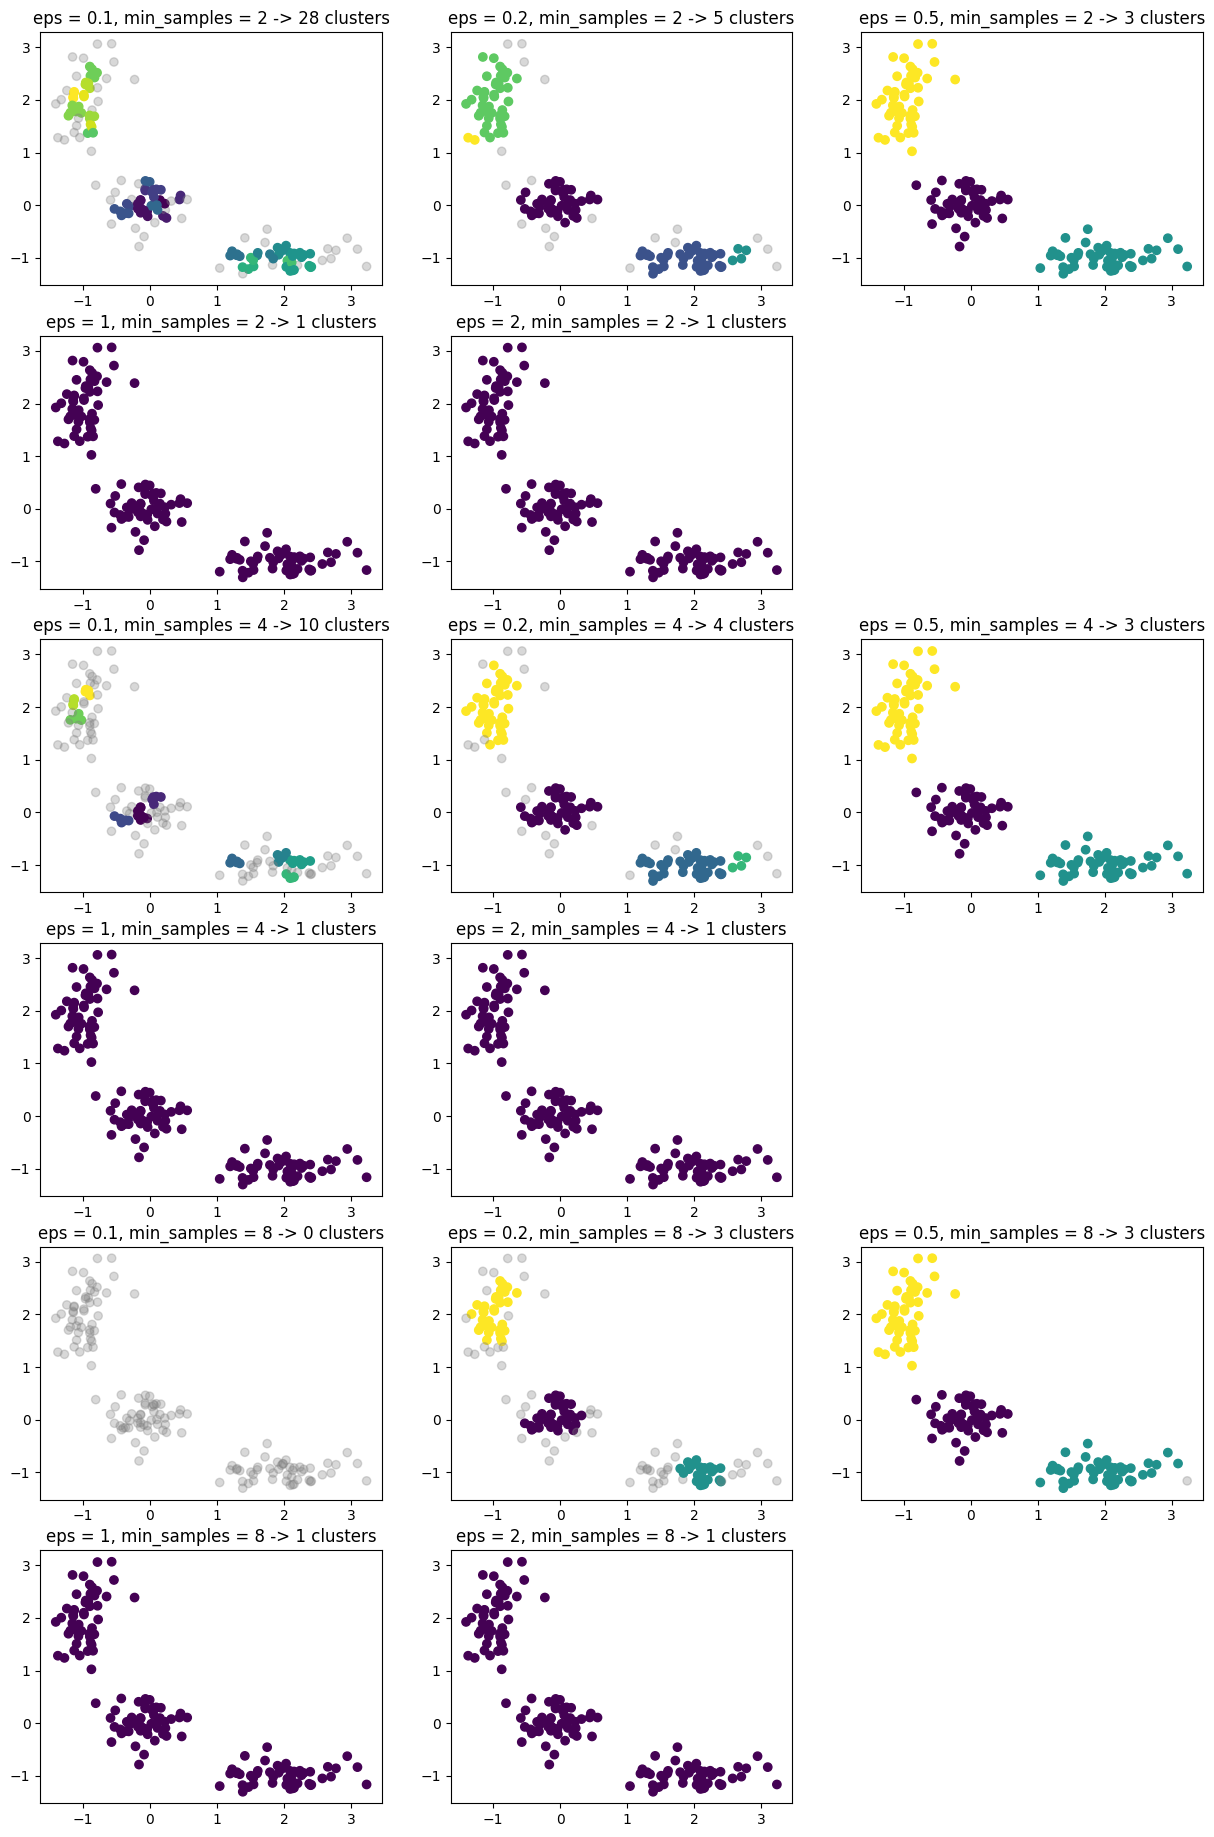

In [ ]:
from sklearn.cluster import DBSCAN
import matplotlib as mpl

# Определим специальную функцию, которая выдаст цвета для кластеров, сделав шум серо-прозрачным
def get_colors(clusters):
  n_clusters = len(np.unique(clusters[clusters != -1]))

  palette = mpl.colormaps['viridis'].resampled(n_clusters)(np.linspace(0, 1, n_clusters))
  colors = np.zeros((clusters.shape[0], 4))
  colors[clusters != -1] = palette[clusters[clusters != -1]]

  # Шум будет серо-прозрачным
  colors[clusters == -1] = [0.5, 0.5, 0.5, 0.3]

  return colors

plt.figure(figsize= (15,23))
i = 1
for samples in [2, 4, 8]:
    for e in [0.1, 0.2, 0.5, 1, 2]:
        dbscan = DBSCAN(eps=e, min_samples=samples)
        clusters = dbscan.fit_predict(X)
        n_clusters = len(np.unique(clusters[clusters != -1]))
        plt.subplot(6, 3, i)
        plt.scatter(X[:, 0], X[:, 1], c = get_colors(clusters))
        plt.title('eps = {}, min_samples = {} -> {} clusters'.format(e, samples, n_clusters))
        i += 1
    i += 1

plt.show()

Пример, с которым у KMeans были проблемы:

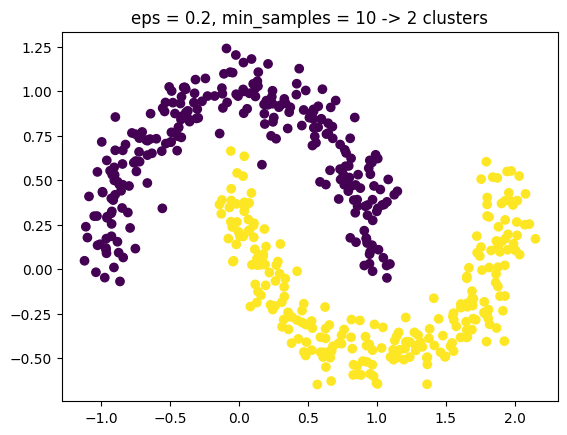

In [ ]:
dbscan = DBSCAN(eps=0.2, min_samples=10)
clusters = dbscan.fit_predict(moons)

colors = get_colors(clusters)
plt.scatter(moons[:, 0], moons[:, 1], c=colors)
plt.title('eps = {}, min_samples = {} -> {} clusters'.format(dbscan.eps, dbscan.min_samples, len(np.unique(clusters[clusters != -1]))))
plt.show()

[Визуализация работы DBSCAN](https://www.naftaliharris.com/blog/visualizing-dbscan-clustering/)

#Визуализация

Пример: кластеризация игроков NBA

In [ ]:
!wget https://raw.githubusercontent.com/Murcha1990/ML_math_2022/main/Семинары/data/sem13-nba-2019.csv

!mv sem13-nba-2019.csv nba-2019.csv

--2026-04-22 06:07:53--  https://raw.githubusercontent.com/Murcha1990/ML_math_2022/main/%D0%A1%D0%B5%D0%BC%D0%B8%D0%BD%D0%B0%D1%80%D1%8B/data/sem13-nba-2019.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 67464 (66K) [text/plain]
Saving to: ‘sem13-nba-2019.csv’

sem13-nba-2019.csv  100%[===================>]  65.88K  --.-KB/s    in 0.01s   

2026-04-22 06:07:53 (6.68 MB/s) - ‘sem13-nba-2019.csv’ saved [67464/67464]



In [ ]:
# Либо так:

#!wget https://raw.githubusercontent.com/SergeyKorpachev/math-faculty-ml/refs/heads/main/2026/seminars/seminar12/nba-2019.csv

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

nba = pd.read_csv("nba-2019.csv")
nba.head()

,Rk,Player,Pos,Age,Tm,G,GS,MP,FG,FGA,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,1,Alex Abrines\abrinal01,SG,25,OKC,31,2,588,56,157,...,0.923,5,43,48,20,17,6,14,53,165
1,2,Quincy Acy\acyqu01,PF,28,PHO,10,0,123,4,18,...,0.700,3,22,25,8,1,4,4,24,17
2,3,Jaylen Adams\adamsja01,PG,22,ATL,34,1,428,38,110,...,0.778,11,49,60,65,14,5,28,45,108
3,4,Steven Adams\adamsst01,C,25,OKC,80,80,2669,481,809,...,0.500,391,369,760,124,117,76,135,204,1108
4,5,Bam Adebayo\adebaba01,C,21,MIA,82,28,1913,280,486,...,0.735,165,432,597,184,71,65,121,203,729


In [ ]:
nba.columns

Index(['Rk', 'Player', 'Pos', 'Age', 'Tm', 'G', 'GS', 'MP', 'FG', 'FGA', 'FG%',
       '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA', 'FT%',
       'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS'],
      dtype='object')

Применим kmeans с 5ю кластерами только к числовым столбцам (объявим алгоритм и обучим его с помощью метода fit).

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

numeric_cols = nba._get_numeric_data().dropna(axis=1)

kmeans = KMeans(n_clusters=5, random_state=3)
kmeans.fit(numeric_cols)

KMeans(n_clusters=5, random_state=3)

In [ ]:
numeric_cols.shape

(530, 22)

С визуализацие могут быть проблемы, так как размерность пространства = 22.

Требуется: понизить размерность до 2, чтобы можно было нарисовать график.

Подходы:
* Метод главных компонент (PCA) - уменьшаем размерность с наименьшими потерями информации.  Может применяться просто для понимжения размерности (не только для визуализации)
* Стохастическое вложение соседей с t-распределением (t-SNE) -  техникой нелинейного снижения размерности, метод моделирует каждый объект высокой размерности новой точкой таким образом, что похожие объекты моделируются близко расположенными точками, а непохожие точки моделируются с большой вероятностью точками, далеко друг от друга отстоящими. Используется для визуализации.


Визуализируем данные с помощью метода главных компонент с n_components = 2:

    1) Применим метод главных компонент
    
    2) Нарисуем полученные точки на плоскости, раскрашенные в цвета, соответствующие кластерам (см. пример выше)

Text(0, 0.5, 'y')

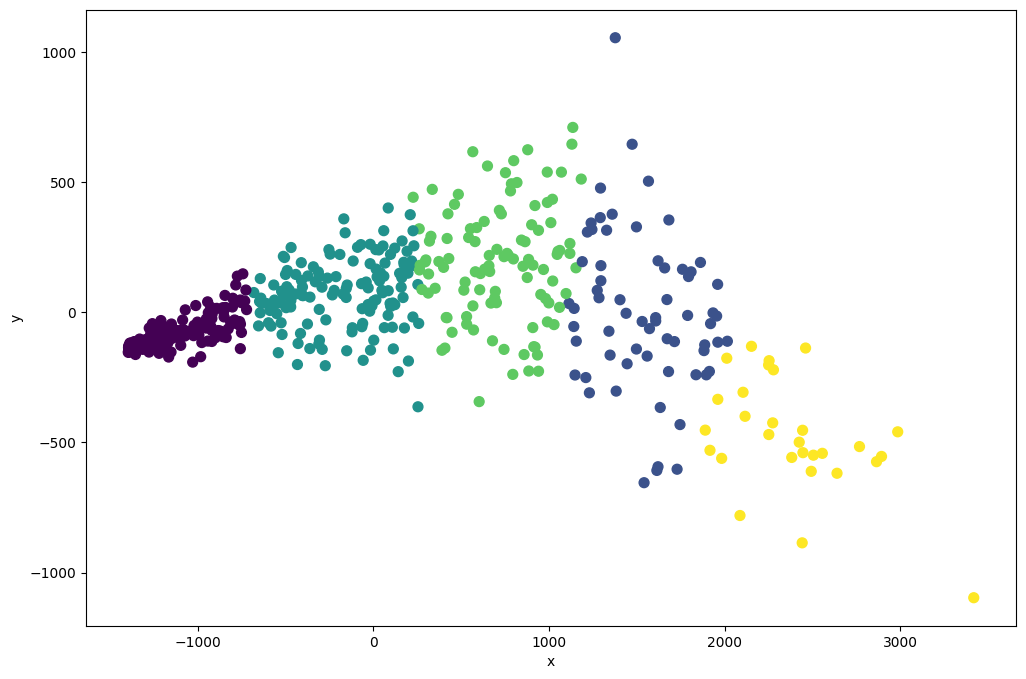

In [ ]:
pca = PCA(n_components=2)
res = pca.fit_transform(numeric_cols)

plt.figure(figsize=(12, 8))
plt.scatter(res[:, 0], res[:, 1], c=kmeans.labels_, s=50, cmap='viridis')
plt.xlabel('x')
plt.ylabel('y')

Text(0, 0.5, 'y')

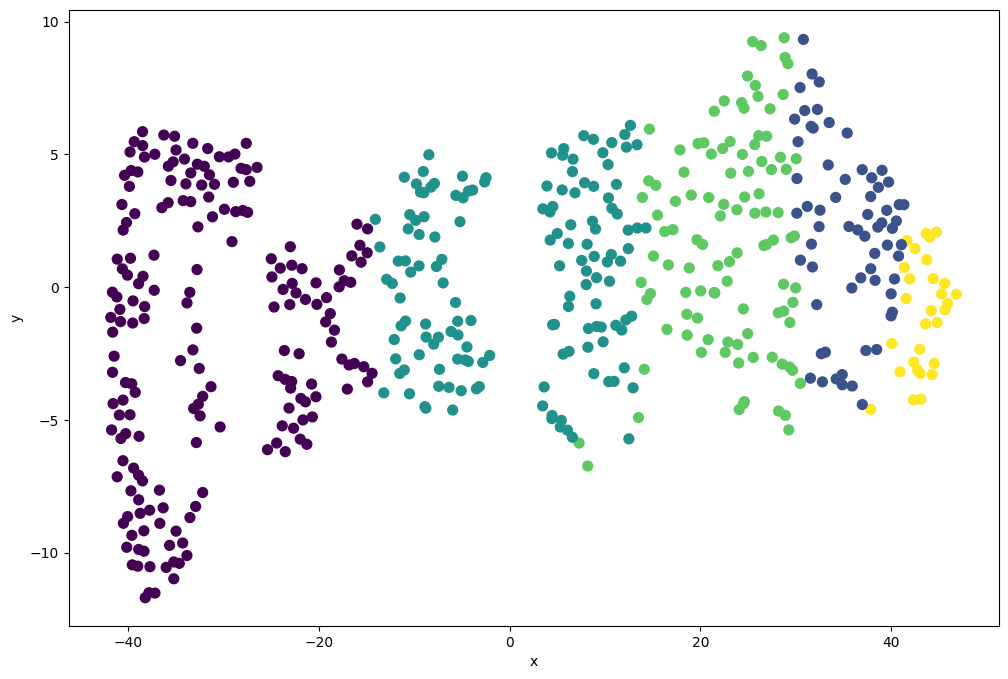

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(random_state=17)
res = tsne.fit_transform(numeric_cols)

plt.figure(figsize=(12, 8))
plt.scatter(res[:, 0], res[:, 1], c=kmeans.labels_, s=50, cmap='viridis')
plt.xlabel('x')
plt.ylabel('y')

Посмотрим, какое смысловое значение несут кластеры.

1) Визуализируем точки в осях nba['pts'] (total points) и nba['ast'] (total assistances) и раскрасим их в цвета кластеров.

2) Визуализируем точки в осях nba['age'] (age) и nba['mp'] (minutes played) и раскрасим их в цвета кластеров.

Подпишем оси.

Text(0, 0.5, 'assistances')

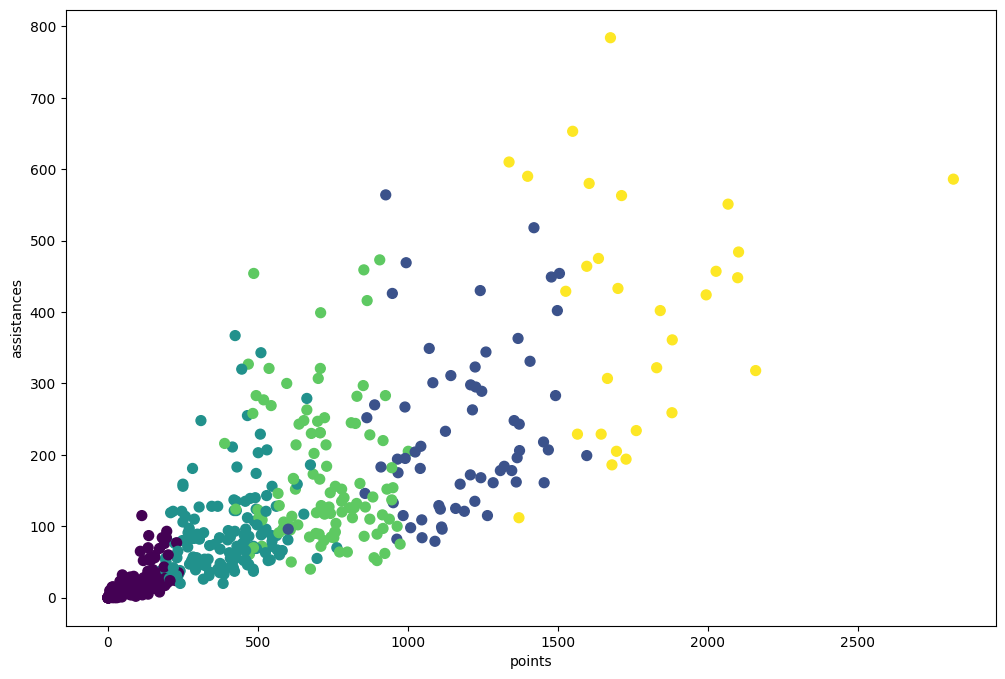

In [ ]:
plt.figure(figsize=(12, 8))
plt.scatter(nba['PTS'], nba['AST'], c=kmeans.labels_, s=50, cmap='viridis')
plt.xlabel('points')
plt.ylabel('assistances')

Text(0, 0.5, 'minutes played')

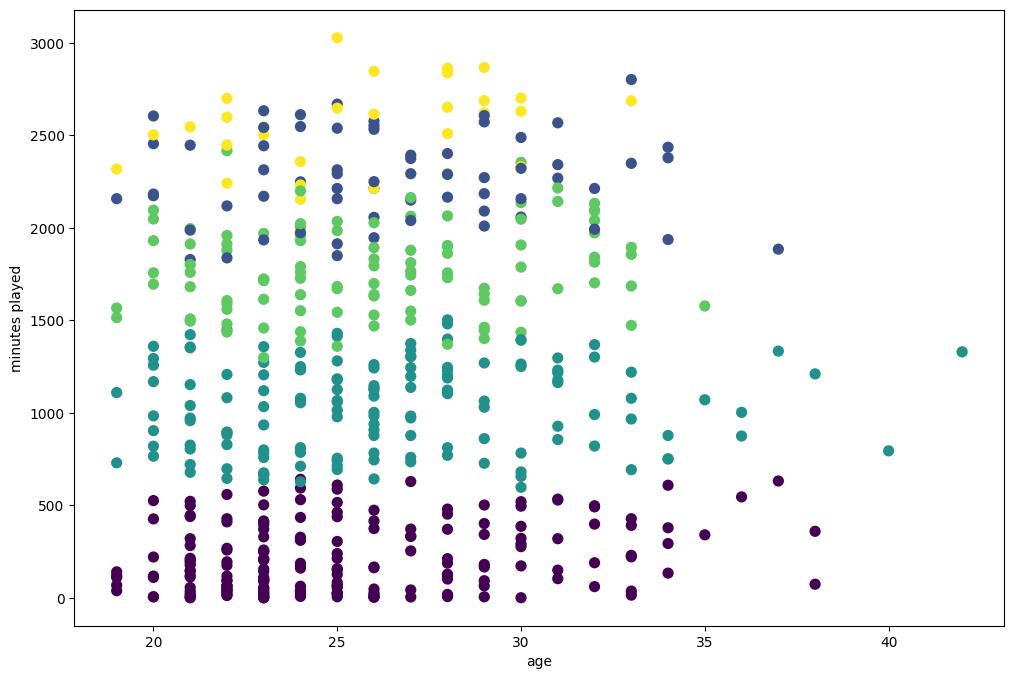

In [ ]:
plt.figure(figsize=(12 ,8))
plt.scatter(nba['Age'], nba['MP'], c=kmeans.labels_, s=50, cmap='viridis')
plt.xlabel('age')
plt.ylabel('minutes played')

# Примеры

## Сжатие изображений с K-means

In [ ]:
!wget https://raw.githubusercontent.com/Murcha1990/ML_math_2022/main/Семинары/data/sem13-cat.jpg

!mv sem13-cat.jpg cat.jpg

--2026-04-22 06:08:40--  https://raw.githubusercontent.com/Murcha1990/ML_math_2022/main/%D0%A1%D0%B5%D0%BC%D0%B8%D0%BD%D0%B0%D1%80%D1%8B/data/sem13-cat.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7131 (7.0K) [image/jpeg]
Saving to: ‘sem13-cat.jpg’

sem13-cat.jpg       100%[===================>]   6.96K  --.-KB/s    in 0s      

2026-04-22 06:08:40 (68.3 MB/s) - ‘sem13-cat.jpg’ saved [7131/7131]



In [ ]:
# Либо так:

#!wget https://raw.githubusercontent.com/SergeyKorpachev/math-faculty-ml/refs/heads/main/2026/seminars/seminar12/cat.jpg

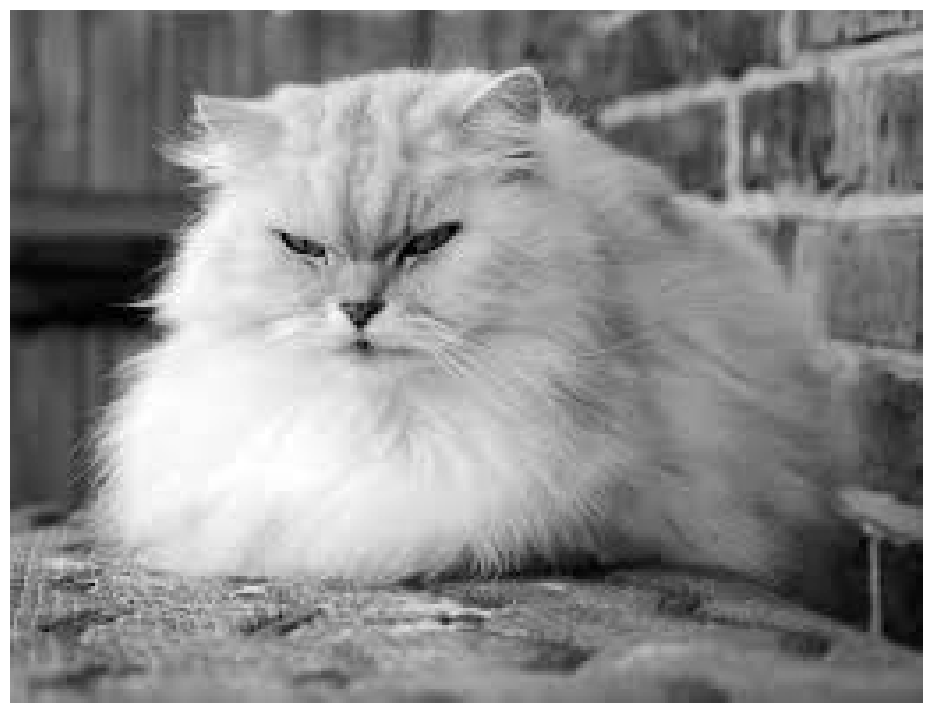

In [ ]:
import matplotlib.image as mpimg

img = mpimg.imread('cat.jpg')[..., 1]
plt.figure(figsize = (15, 9))
plt.axis('off')
plt.imshow(img, cmap='gray');

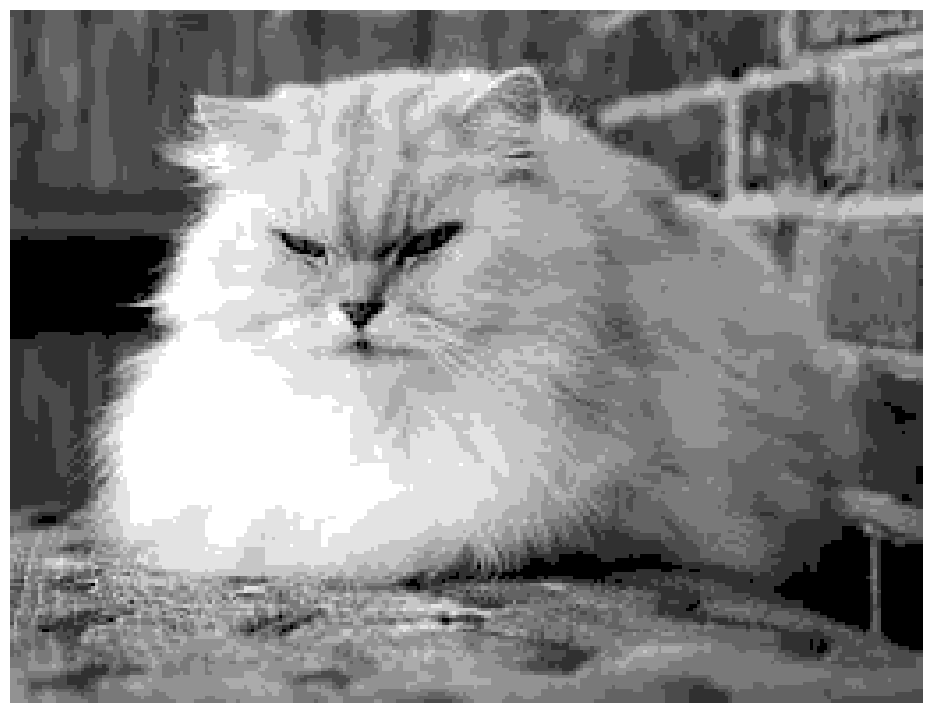

In [ ]:
from sklearn.cluster import MiniBatchKMeans
from scipy.stats import randint

X = img.reshape((-1, 1)) # вытягиваем картинку в вектор
k_means = MiniBatchKMeans(n_clusters=10)
k_means.fit(X)
values = k_means.cluster_centers_
labels = k_means.labels_

img_compressed = values[labels].reshape(img.shape) # возвращаем к размерности исходной картинки

plt.figure(figsize = (15, 9))
plt.axis('off')
plt.imshow(img_compressed, cmap = 'gray');

Возьмите любую фотографию (можно работать с той же) и подберите минимальное число кластеров, которое визуально не ухудшает качество изображения.

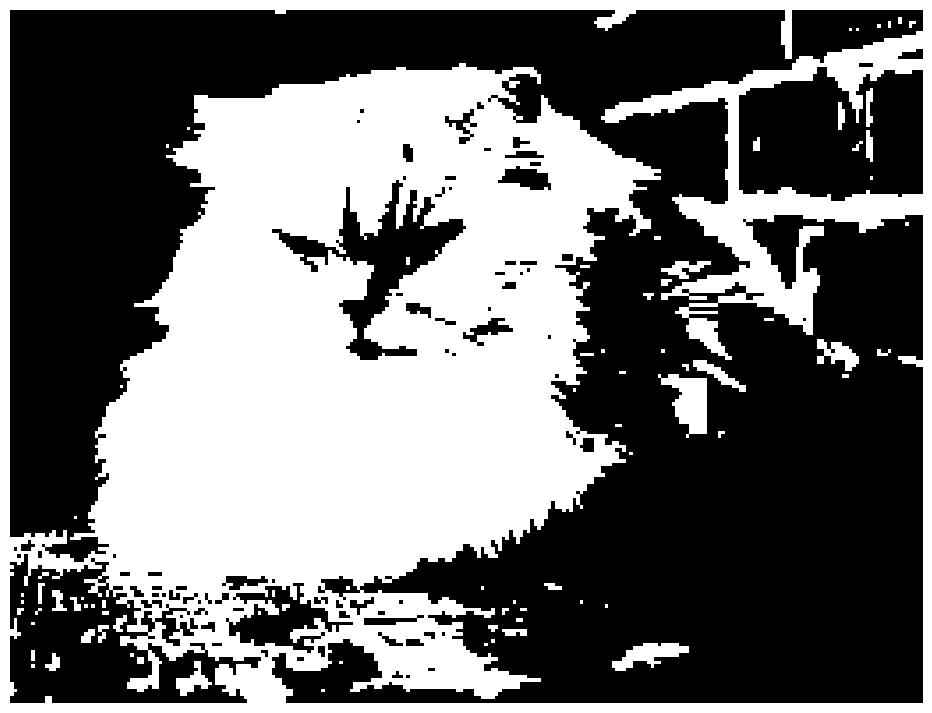

In [ ]:
# Ваш код сюда :)

from sklearn.cluster import MiniBatchKMeans
from scipy.stats import randint

X = img.reshape((-1, 1)) # вытягиваем картинку в вектор
k_means = MiniBatchKMeans(n_clusters=2)
k_means.fit(X)
values = k_means.cluster_centers_
labels = k_means.labels_

img_compressed = values[labels].reshape(img.shape) # возвращаем к размерности исходной картинки

plt.figure(figsize = (15, 9))
plt.axis('off')
plt.imshow(img_compressed, cmap = 'gray');

## Нахождение тем в текстах

Применим KMeans для кластеризации текстов из 4 новостных категорий.

In [ ]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.preprocessing import Normalizer
from sklearn import metrics
from time import time

categories = [
    'talk.politics.misc',
    'talk.religion.misc',
    'comp.graphics',
    'sci.space']

print("Loading 20 newsgroups dataset for categories:")
print(categories)

dataset = fetch_20newsgroups(subset='all', categories=categories,
                             shuffle=True, random_state=42)

print("%d documents" % len(dataset.data))
print("%d categories" % len(dataset.target_names))

labels = dataset.target
true_k = np.unique(labels).shape[0]

Loading 20 newsgroups dataset for categories:
['talk.politics.misc', 'talk.religion.misc', 'comp.graphics', 'sci.space']
3363 documents
4 categories


Закодируем тексты с помощью TF-IDF признаков.

![How](https://raw.githubusercontent.com/Murcha1990/ML_math_2022/main/Семинары/images/tf-idf.png)

In [ ]:
print("Extracting features from the training dataset using a sparse vectorizer")
vectorizer = TfidfVectorizer(max_df=0.5, max_features=1000,
                             min_df=2, stop_words='english')

X = vectorizer.fit_transform(dataset.data)
print("n_samples: %d, n_features: %d" % X.shape)

Extracting features from the training dataset using a sparse vectorizer
n_samples: 3363, n_features: 1000


И применим к получившимся векторам метод $k$ средних и выведем метрики качества кластеризации.

Так как есть настоящие лейблы (темы текстов), то можно посчитать внешние меры качества кластеризации (те, которые оценивают, насколько полученная кластеризация похожа на настоящую разметку).

Вопрос: почему нельзя просто использовать метрику качества классификации?

In [ ]:
km = KMeans(n_clusters=true_k, init='k-means++', max_iter=100, n_init=1)

print("Clustering sparse data with %s" % km)
t0 = time()
km.fit(X)

print("Homogeneity: %0.3f" % metrics.homogeneity_score(labels, km.labels_))
print("Completeness: %0.3f" % metrics.completeness_score(labels, km.labels_))
print("V-measure: %0.3f" % metrics.v_measure_score(labels, km.labels_))
print("Adjusted Rand-Index: %.3f"
      % metrics.adjusted_rand_score(labels, km.labels_))
print("Adjusted mutual info score: %.3f"
      % metrics.adjusted_mutual_info_score(labels, km.labels_))

print("Silhouette Coefficient: %0.3f"
      % metrics.silhouette_score(X, km.labels_, sample_size=1000))

order_centroids = km.cluster_centers_.argsort()[:, ::-1]

Clustering sparse data with KMeans(max_iter=100, n_clusters=4, n_init=1)
Homogeneity: 0.507
Completeness: 0.606
V-measure: 0.552
Adjusted Rand-Index: 0.499
Adjusted mutual info score: 0.552
Silhouette Coefficient: 0.015


Выведем слова, соответствующие самым весомым компонентам центров кластеров.

In [ ]:
terms = vectorizer.get_feature_names_out()
for i in range(true_k):
    print("Cluster %d:" % (i + 1), end='')
    for ind in order_centroids[i, :10]:
        print(' %s' % terms[ind], end='')
    print()

Cluster 1: graphics university thanks image file ac posting host nntp files
Cluster 2: henry toronto zoo spencer zoology space launch work orbit umd
Cluster 3: space nasa access gov digex pat shuttle alaska moon com
Cluster 4: com people god don just cramer think know government like


## Кластеризация рукописных цифр

In [ ]:
from sklearn.datasets import load_digits

digits = load_digits()

X, y = digits.data, digits.target
Im = digits.images

Выведем на экран первые 20 цифр (в цветовой схеме 'gray')

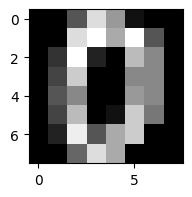

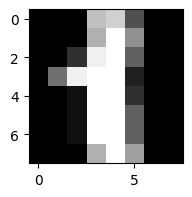

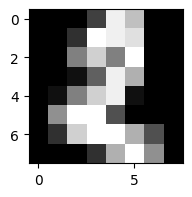

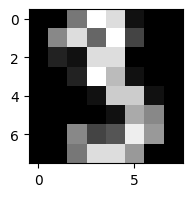

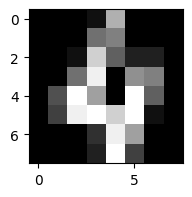

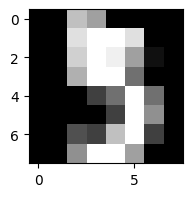

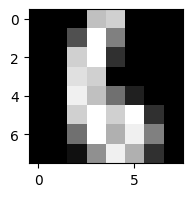

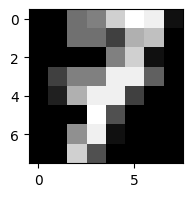

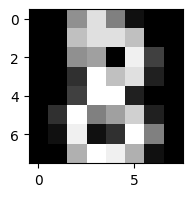

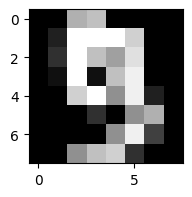

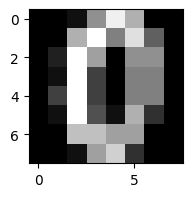

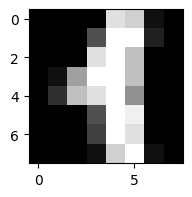

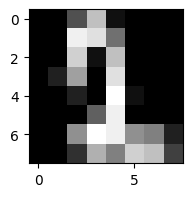

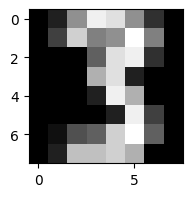

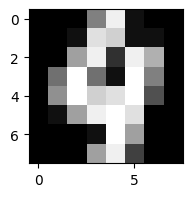

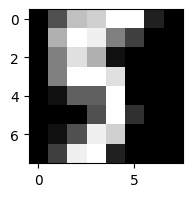

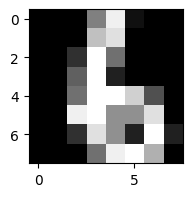

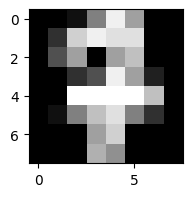

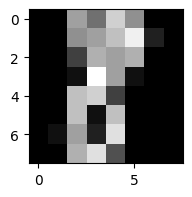

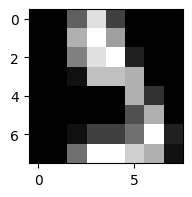

In [ ]:
for i in range(20):
    plt.figure(figsize=(2, 2))
    plt.imshow(Im[i], cmap='gray')
    plt.show()

Обучим kmeans с десятью кластерами.

In [ ]:
km = KMeans(n_clusters=10, init='k-means++', max_iter=100, n_init=1)
km.fit(X)

KMeans(max_iter=100, n_clusters=10, n_init=1)

Выведем на экран метрики качества кластеризации

In [ ]:
labels = digits.target

print("Homogeneity: %0.3f" % metrics.homogeneity_score(labels, km.labels_))
print("Completeness: %0.3f" % metrics.completeness_score(labels, km.labels_))
print("V-measure: %0.3f" % metrics.v_measure_score(labels, km.labels_))
print("Adjusted Rand-Index: %.3f"
      % metrics.adjusted_rand_score(labels, km.labels_))
print("Adjusted mutual info score: %.3f"
      % metrics.adjusted_mutual_info_score(labels, km.labels_))

print("Silhouette Coefficient: %0.3f"
      % metrics.silhouette_score(X, km.labels_, sample_size=1000))

order_centroids = km.cluster_centers_.argsort()[:, ::-1]

Homogeneity: 0.745
Completeness: 0.758
V-measure: 0.751
Adjusted Rand-Index: 0.673
Adjusted mutual info score: 0.749
Silhouette Coefficient: 0.173


Нарисуем центры получившихся кластеров.

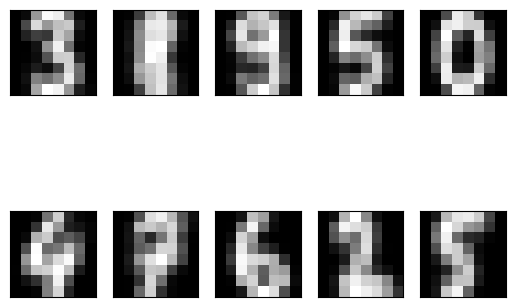

In [ ]:
_, axes = plt.subplots(2, 5)
for ax, center in zip(axes.ravel(), km.cluster_centers_):
    ax.matshow(center.reshape(8, 8), cmap=plt.cm.gray)
    ax.set_xticks(())
    ax.set_yticks(())

Кластеризация получилась довольно качественной. Визуализируем наши объекты (изображения цифр) как точки на двумерной плоскости.

Визуализируем данные с помощью PCA с двумя компонентами

CPU times: user 69.2 ms, sys: 964 µs, total: 70.2 ms
Wall time: 40.2 ms


<timed exec>:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.


Text(0.5, 1.0, 'MNIST. PCA reduction')

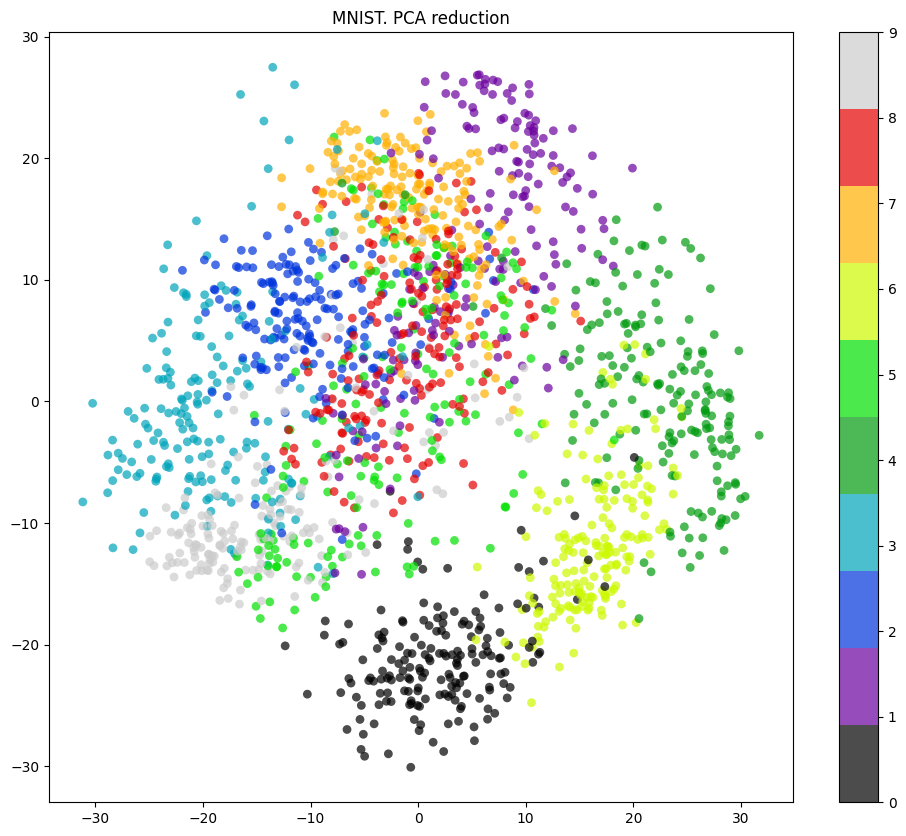

In [ ]:
%%time

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)

plt.figure(figsize=(12,10))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y,
            edgecolor='none', alpha=0.7, s=40,
            cmap=plt.cm.get_cmap('nipy_spectral', 10))
plt.colorbar()
plt.title('MNIST. PCA reduction');

Визуализируем данные с помощью t-SNE

CPU times: user 14.8 s, sys: 22.5 ms, total: 14.8 s
Wall time: 14.7 s


<timed exec>:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.


Text(0.5, 1.0, 'MNIST. t-SNE projection')

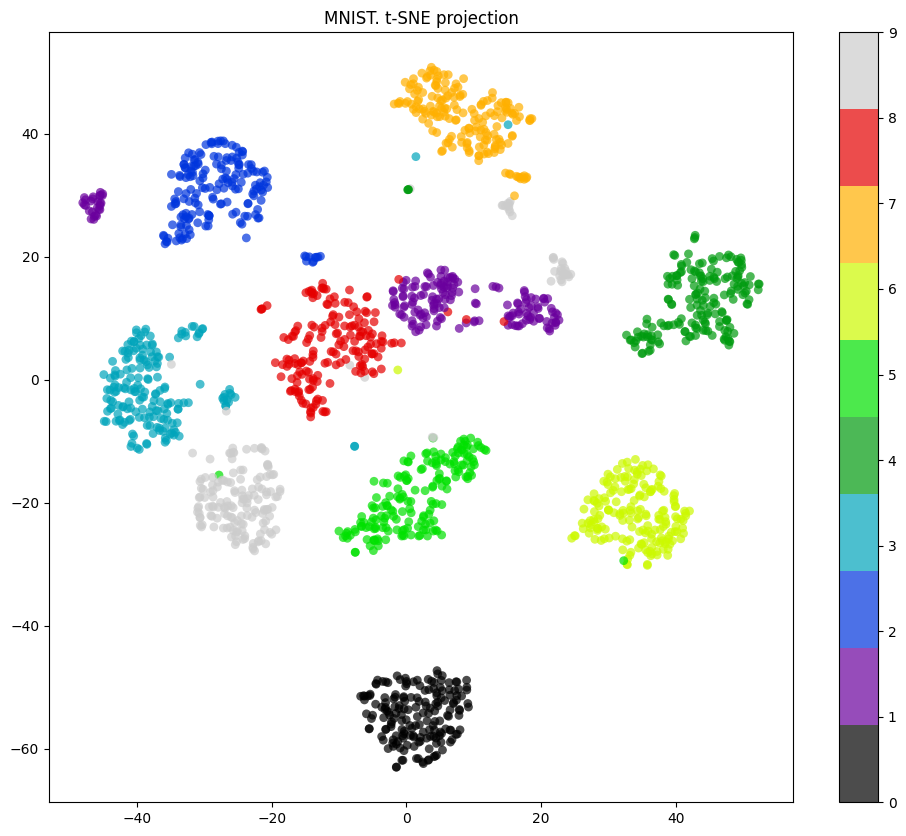

In [ ]:
%%time

from sklearn.manifold import TSNE

tsne = TSNE(random_state=17)
X_tsne = tsne.fit_transform(X) # две координаты

plt.figure(figsize=(12, 10))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y,
            edgecolor='none', alpha=0.7, s=40,
            cmap=plt.cm.get_cmap('nipy_spectral', 10))
plt.colorbar()
plt.title('MNIST. t-SNE projection');

## Полезные ссылки
- <a href="https://en.wikipedia.org/wiki/K-means_clustering">k-means</a> на Википедии
- <a href="https://scikit-learn.org/stable/modules/clustering.html">обзор</a> методов кластеризации в sklearn

# Если будет время попрактиковаться...

В этом задании мы попрактикуемся в методах снижения размерности и кластеризации данных.

Мы будем работать с набором данных Samsung Human Activity Recognition. Данные поступают с акселерометров и гироскопов мобильных телефонов Samsung Galaxy S3, также известен вид активности человека с телефоном в кармане – ходил ли он, стоял, лежал, сидел или шел вверх/вниз по лестнице.

Представим, что вид активности нам неизвестнен, и попробуем кластеризовать людей чисто на основе имеющихся признаков.

In [ ]:
# Загрузим данные

!wget https://raw.githubusercontent.com/juanlurg/samsung-human-activity/master/data/samsung_test.txt
!wget https://raw.githubusercontent.com/juanlurg/samsung-human-activity/master/data/samsung_train.txt
!wget https://raw.githubusercontent.com/juanlurg/samsung-human-activity/master/data/samsung_test_labels.txt
!wget https://raw.githubusercontent.com/juanlurg/samsung-human-activity/master/data/samsung_train_labels.txt

--2026-04-22 06:09:54--  https://raw.githubusercontent.com/juanlurg/samsung-human-activity/master/data/samsung_test.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 26455219 (25M) [text/plain]
Saving to: ‘samsung_test.txt’

samsung_test.txt    100%[===================>]  25.23M  --.-KB/s    in 0.1s    

2026-04-22 06:09:55 (234 MB/s) - ‘samsung_test.txt’ saved [26455219/26455219]

--2026-04-22 06:09:55--  https://raw.githubusercontent.com/juanlurg/samsung-human-activity/master/data/samsung_train.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting respons

In [ ]:
import numpy as np
import seaborn as sns
from tqdm import tqdm_notebook

%matplotlib inline

from matplotlib import pyplot as plt
plt.style.use(['seaborn-v0_8-darkgrid'])
plt.rcParams['figure.figsize'] = (12, 9)
plt.rcParams['font.family'] = 'DejaVu Sans'

from sklearn import metrics
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

RANDOM_STATE = 17

In [ ]:
X_train = np.loadtxt("samsung_train.txt")
y_train = np.loadtxt("samsung_train_labels.txt").astype(int)

X_test = np.loadtxt("samsung_test.txt")
y_test = np.loadtxt("samsung_test_labels.txt").astype(int)

Для кластеризации нам не нужен вектор ответов. Объедините обучающую и тестовую выборки.

In [ ]:
# Ваш код сюда :)

X = np.vstack((X_train, X_test))
y = np.hstack((y_train, y_test))

print(f"Размер X: {X.shape}")
print(f"Размер y: {y.shape}")

Размер X: (10299, 561)
Размер y: (10299,)


In [ ]:
np.unique(y)

array([1, 2, 3, 4, 5, 6])

Эти метки соответствуют:

1 - ходьбе,
2 - подъему вверх по лестнице,
3 - спуску по лестнице,
4 - сидению,
5 - стоянию,
6 - лежанию

Отмасштабируйте выборку с помощью StandardScaler.

In [ ]:
# Ваш код сюда :)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Понижаем размерность с помощью PCA, оставляя столько компонент, сколько нужно для того, чтобы объяснить как минимум 90% дисперсии исходных (отмасштабированных) данных. Используйте отмасштабированную выборку и зафиксируйте random_state.

In [ ]:
# Ваш код сюда :)

pca = PCA(n_components=0.9, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

Визуализируйте данные в проекции на первые две главные компоненты.

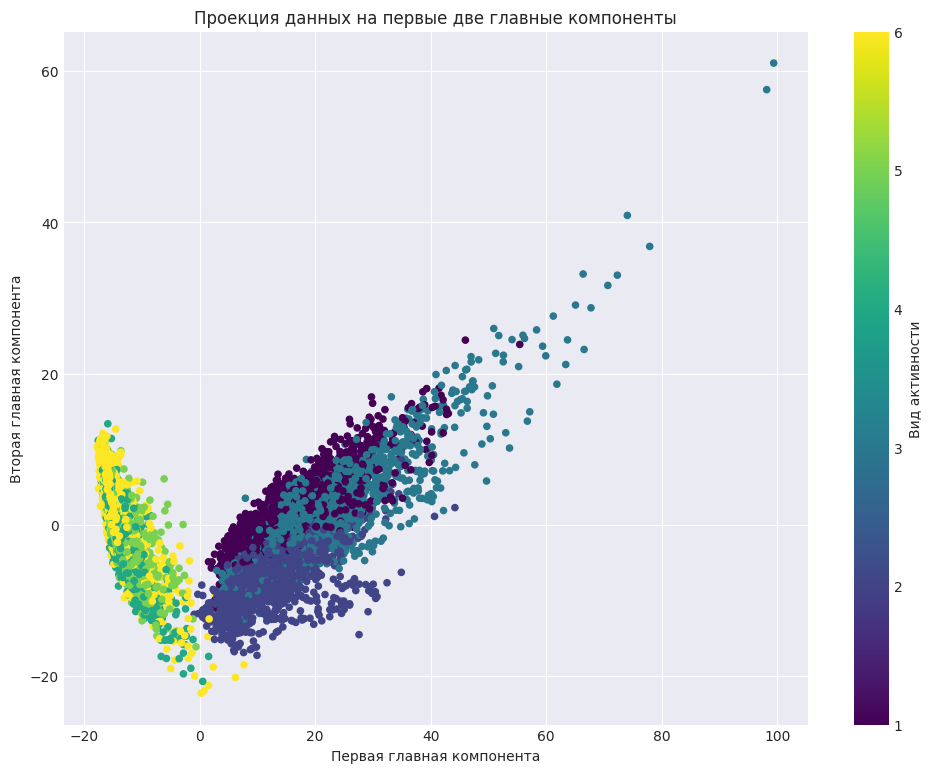

In [ ]:
# Ваш код сюда :)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, s=20, cmap='viridis')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.title('Проекция данных на первые две главные компоненты')
plt.colorbar(label='Вид активности')
plt.show();

Сделайте кластеризацию данных методом KMeans, обучив модель на данных со сниженной за счет PCA размерностью. В данном случае нужно искать 6 кластеров (так как у нас 6 классов).

Параметры:

n_clusters = n_classes (число уникальных меток целевого класса)

n_init = 100

random_state = RANDOM_STATE (для воспроизводимости результата)

In [ ]:
# Ваш код сюда :)

# Определяем количество уникальных классов
n_classes = len(np.unique(y))
print(f"Количество кластеров: {n_classes}")

kmeans = KMeans(
    n_clusters=n_classes,
    n_init=100,
    random_state=RANDOM_STATE
)

kmeans.fit(X_pca)

y_kmeans = kmeans.labels_

Количество кластеров: 6


Визуализируйте данные в проекции на первые две главные компоненты. Раскрасьте точки в соответствии с полученными метками кластеров.

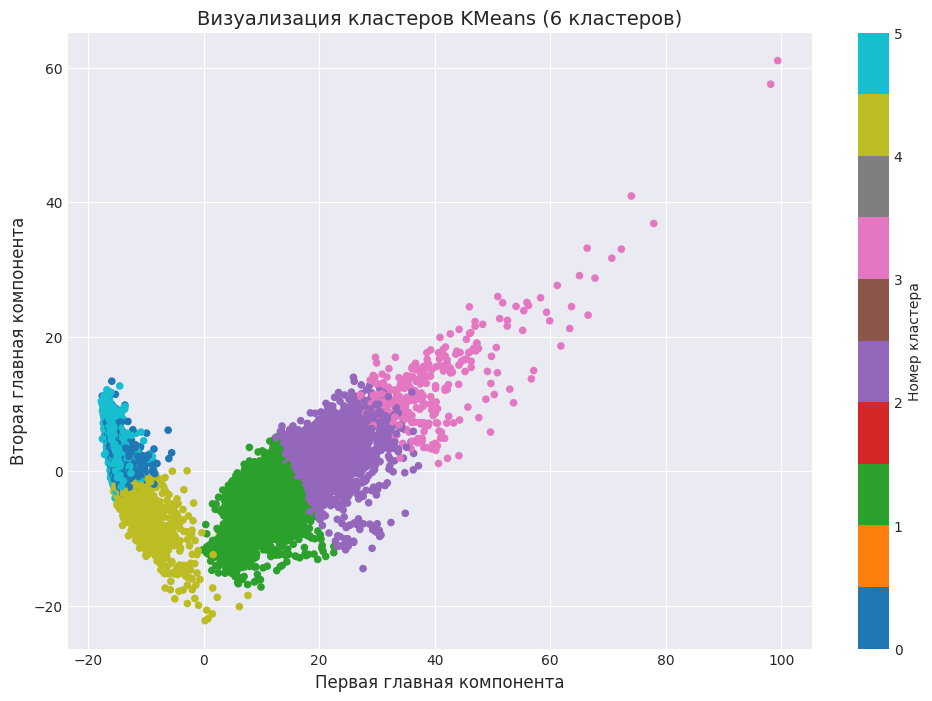

In [ ]:
# Ваш код сюда :)

plt.figure(figsize=(12, 8))

scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_kmeans, s=20, cmap='tab10')

plt.xlabel('Первая главная компонента', fontsize=12)
plt.ylabel('Вторая главная компонента', fontsize=12)
plt.title('Визуализация кластеров KMeans (6 кластеров)', fontsize=14)

plt.colorbar(scatter, label='Номер кластера', ticks=range(6))

plt.show()

Выведите на экран значения метрик качества кластеризации

In [ ]:
# Ваш код сюда :)

from sklearn.metrics import (adjusted_rand_score, normalized_mutual_info_score,
                             homogeneity_score, completeness_score, v_measure_score)

ari = adjusted_rand_score(y, y_kmeans)
nmi = normalized_mutual_info_score(y, y_kmeans)
homogeneity = homogeneity_score(y, y_kmeans)
completeness = completeness_score(y, y_kmeans)
v_measure = v_measure_score(y, y_kmeans)

print("Оценка качества кластеризации KMeans:")
print(f"Adjusted Rand Index (ARI):    {ari:.4f}")
print(f"Normalized Mutual Info (NMI): {nmi:.4f}")
print(f"Homogeneity:                  {homogeneity:.4f}")
print(f"Completeness:                 {completeness:.4f}")
print(f"V-measure:                    {v_measure:.4f}")

Оценка качества кластеризации KMeans:
Adjusted Rand Index (ARI):    0.4198
Normalized Mutual Info (NMI): 0.5602
Homogeneity:                  0.5408
Completeness:                 0.5812
V-measure:                    0.5602


Теперь попробуем сделать кластеризацию с помощью AgglomerativeClustering (https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html)

In [ ]:
ag = AgglomerativeClustering(n_clusters=n_classes,
                             linkage='ward').fit(X_pca)

y_ag = ag.labels_

Выведите метрики качества для полученного разбиения на кластеры. Сравните с kmeans. Запишите выводы!

In [ ]:
# Ваш код сюда :)

# Функция для сравнения
def compare_clustering(y_true, y_pred1, y_pred2, name1="KMeans", name2="Agglomerative"):
    metrics_names = ["ARI", "NMI", "Homogeneity", "Completeness", "V-measure"]
    scores1 = [
        adjusted_rand_score(y_true, y_pred1),
        normalized_mutual_info_score(y_true, y_pred1),
        homogeneity_score(y_true, y_pred1),
        completeness_score(y_true, y_pred1),
        v_measure_score(y_true, y_pred1)
    ]
    scores2 = [
        adjusted_rand_score(y_true, y_pred2),
        normalized_mutual_info_score(y_true, y_pred2),
        homogeneity_score(y_true, y_pred2),
        completeness_score(y_true, y_pred2),
        v_measure_score(y_true, y_pred2)
    ]

    print(f"\n{'Метрика':<15} {name1:<12} {name2:<15}")
    print("-" * 45)
    for name, s1, s2 in zip(metrics_names, scores1, scores2):
        print(f"{name:<15} {s1:.4f}        {s2:.4f}")
        print(f"  Разница: {s2 - s1:+.4f}")

    if scores1[0] > scores2[0]:
        print(f"\n {name1} лучше по ARI")
    else:
        print(f"\n {name2} лучше по ARI")

compare_clustering(y, y_kmeans, y_ag)


Метрика         KMeans       Agglomerative  
---------------------------------------------
ARI             0.4198        0.4936
  Разница: +0.0738
NMI             0.5602        0.6218
  Разница: +0.0616
Homogeneity     0.5408        0.5779
  Разница: +0.0371
Completeness    0.5812        0.6729
  Разница: +0.0917
V-measure       0.5602        0.6218
  Разница: +0.0616

 Agglomerative лучше по ARI


Попробуйте применить другие методы кластеризации из sklearn. Также вычислите метрики качества и сделайте вывод о том, какой метод сработал лучше.

In [ ]:
# Ваш код сюда :)


In [ ]:
# Ваш код сюда :)
